# Multi-class Classification
Building a small neural network to classify data into more than two categories, and examining what each unit learns.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
np.set_printoptions(precision=2)

### Prepare data
Create a 4-class dataset using make_blobs.

In [3]:
classes = 4                    # number of categories to classify
m = 100                        # number of training examples to generate
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]   # center point for each of the 4 clusters
std = 1.0                      # spread of each cluster around its center

# generate 100 fake 2D points scattered around the 4 centers, one cluster per class
X_train, y_train = make_blobs(n_samples=m, centers=centers, cluster_std=std, random_state=30)

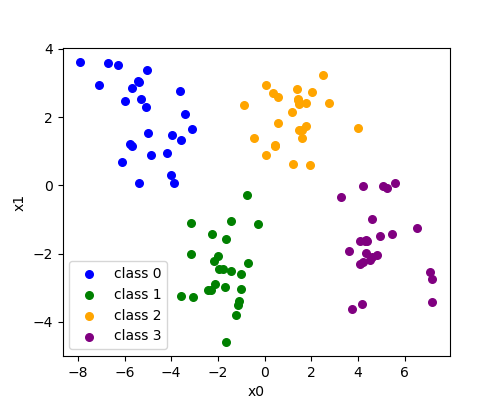

In [4]:
def plt_mc(X, y, classes, centers, std=1.0):
    fig, ax = plt.subplots(1,1,figsize=(5,4))
    colors = ['blue','green','orange','purple']
    for c in range(classes):
        ax.scatter(X[y==c,0], X[y==c,1], c=colors[c], label=f"class {c}", s=30)
    ax.set_xlabel("x0")
    ax.set_ylabel("x1")
    ax.legend()
    plt.savefig("multiclass_data.png")
    plt.close()
    from IPython.display import Image
    return Image("multiclass_data.png")

plt_mc(X_train, y_train, classes, centers, std=std)

In [5]:
print(f"unique classes {np.unique(y_train)}")
print(f"class representation {y_train[:10]}")
print(f"shape of X_train: {X_train.shape}, shape of y_train: {y_train.shape}")

unique classes [0 1 2 3]
class representation [3 3 3 0 3 3 3 3 2 0]
shape of X_train: (100, 2), shape of y_train: (100,)


In [8]:
tf.random.set_seed(1234)
model = Sequential([
    Dense(2, activation='relu', name="L1"),
    Dense(4, activation='linear', name="L2")
])
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(0.01),
)
model.fit(X_train, y_train, epochs=200)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.9793  
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.7750 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6042 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4603 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3407 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2423 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1610 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0934 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0394 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9981 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9672 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9411 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9174 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8952 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8744 
Epoch 16/200
4/4 ━

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step


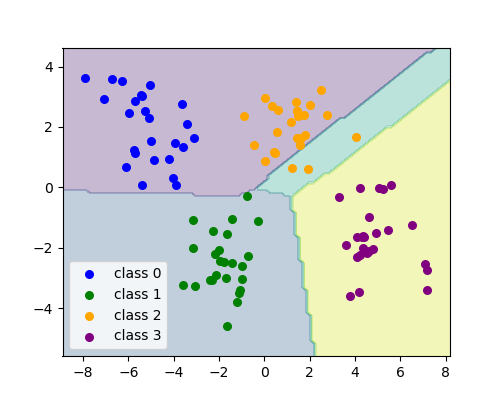

In [9]:
def plt_cat_mc(X, y, model, classes):
    x0 = np.linspace(np.min(X[:,0])-1, np.max(X[:,0])+1, 100)
    x1 = np.linspace(np.min(X[:,1])-1, np.max(X[:,1])+1, 100)
    X0, X1 = np.meshgrid(x0, x1)
    grid = np.c_[X0.ravel(), X1.ravel()]
    Z = np.argmax(model.predict(grid), axis=1).reshape(X0.shape)

    fig, ax = plt.subplots(1,1,figsize=(5,4))
    ax.contourf(X0, X1, Z, alpha=0.3, cmap='viridis')
    colors = ['blue','green','orange','purple']
    for c in range(classes):
        ax.scatter(X[y==c,0], X[y==c,1], c=colors[c], label=f"class {c}", s=30)
    ax.legend()
    plt.savefig("multiclass_boundaries.png")
    plt.close()
    from IPython.display import Image
    return Image("multiclass_boundaries.png")

plt_cat_mc(X_train, y_train, model, classes)

In [10]:
l1 = model.get_layer("L1")
W1, b1 = l1.get_weights()
print("W1:\n", W1, "\nb1:", b1)

W1:
 [[-0.03  0.87]
 [-1.46 -1.52]] 
b1: [1.   0.63]
